# Comprehensive System Evaluation & Benchmarking

This notebook evaluates different Vision-Language Models (VLMs) for the Real-Time Scene Description & Danger Detection System. 
We compare them based on:
- **Latency (ms)** for real-time constraints (<300ms)
- **GPU Memory Usage** (Memory footprint)
- **Quality Metrics**: BLEU, ROUGE, METEOR
- **Performance on Inputs**: Both static Images and sampled Video frames.


In [8]:
!pip install -q torch torchvision pandas matplotlib transformers accelerate Pillow opencv-python evaluate rouge-score nltk sacrebleu
import nltk
nltk.download('wordnet')
nltk.download('punkt')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
import os
import time
import torch
import cv2
import re
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import Dict, Tuple, Any, List
import evaluate

# Load metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## 1. Setup Models & Classes
We define the `Captioner` class to support multiple model architectures (`BLIP`, `GIT`, `ViT-GPT2`, and placeholders for heavy models like `Qwen-VL`).


In [10]:
class Captioner:
    def __init__(self, model_name: str, device: str = None):
        self.model_name = model_name
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Loading {model_name} on {self.device}...")
        
        self.processor = None
        self.model = None
        self.tokenizer = None
        self.feature_extractor = None
        self._load_model()
        
    def _load_model(self):
        from transformers import BlipProcessor, BlipForConditionalGeneration
        from transformers import AutoProcessor, AutoModelForCausalLM
        from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
        
        dtype = torch.float16 if self.device == "cuda" else torch.float32

        if "blip" in self.model_name.lower():
            self.processor = BlipProcessor.from_pretrained(self.model_name)
            self.model = BlipForConditionalGeneration.from_pretrained(self.model_name, torch_dtype=dtype).to(self.device)
            self.model_type = "blip"
            
        elif "git" in self.model_name.lower():
            self.processor = AutoProcessor.from_pretrained(self.model_name)
            self.model = AutoModelForCausalLM.from_pretrained(self.model_name, torch_dtype=dtype).to(self.device)
            self.model_type = "git"
            
        elif "vit-gpt2" in self.model_name.lower():
            self.model = VisionEncoderDecoderModel.from_pretrained(self.model_name).to(self.device)
            # ViT-GPT2 normally uses float32
            self.feature_extractor = ViTImageProcessor.from_pretrained(self.model_name)
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model_type = "vit-gpt2"
            
        elif "qwen" in self.model_name.lower():
            from transformers import AutoModelForCausalLM, AutoTokenizer
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
            self.model = AutoModelForCausalLM.from_pretrained(self.model_name, device_map=self.device, trust_remote_code=True, fp16=True).eval()
            self.model_type = "qwen"
            
        else:
            raise NotImplementedError(f"Loader for {self.model_name} not configured.")

    def generate_caption(self, image: Image.Image) -> Dict[str, Any]:
        start_time = time.perf_counter()
        
        with torch.no_grad():
            if self.model_type == "blip":
                inputs = self.processor(image, return_tensors="pt").to(self.device, self.model.dtype)
                out = self.model.generate(**inputs, max_new_tokens=40)
                caption = self.processor.decode(out[0], skip_special_tokens=True)
                
            elif self.model_type == "git":
                inputs = self.processor(images=image, return_tensors="pt").to(self.device, self.model.dtype)
                generated_ids = self.model.generate(pixel_values=inputs.pixel_values, max_length=50)
                caption = self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
            elif self.model_type == "vit-gpt2":
                pixel_values = self.feature_extractor(images=image, return_tensors="pt").pixel_values.to(self.device)
                output_ids = self.model.generate(pixel_values, max_length=16, num_beams=4)
                caption = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
                
            elif self.model_type == "qwen":
                # Assuming Qwen-VL specific generation call
                # Note: Qwen natively expects file paths or specific formats, this is a simplified wrapper
                # You might need to save the PIL image to a temp path for Qwen-VL native method
                temp_path = "temp_qwen_input.jpg"
                image.save(temp_path)
                query = self.tokenizer.from_list_format([{'image': temp_path}, {'text': 'Describe the image.'}])
                inputs = self.tokenizer(query, return_tensors='pt').to(self.device)
                pred = self.model.generate(**inputs)
                caption = self.tokenizer.decode(pred.cpu()[0], skip_special_tokens=True)
                
        latency_ms = (time.perf_counter() - start_time) * 1000
        
        return {
            "caption": caption.strip(),
            "latency_ms": latency_ms
        }
        
    def cleanup(self):
        del self.model
        del self.processor
        del self.tokenizer
        del self.feature_extractor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            gc.collect()


In [11]:
class DangerClassifier:
    def __init__(self, window_size: int = 5):
        self.window_size = window_size
        danger_words = ["hole", "puddle", "fire", "accident", "glass", "crash", "manhole", "cliff", "flood", "smoke", "weapon", "knife", "tree", "debris", "obstacle", "gun", "hazard", "stairs", "step"]
        negation_words = ["no", "not", "without", "free", "clear", "safe", "none", "never", "zero"]
        self.danger_pattern = re.compile(rf"\b({'|'.join(danger_words)})s?\b", re.IGNORECASE)
        self.negation_pattern = re.compile(rf"\b({'|'.join(negation_words)})\b", re.IGNORECASE)

    def classify(self, text: str) -> Tuple[str, str]:
        if not text: return "SAFE", "No description"
        text = text.lower()
        danger_matches = list(self.danger_pattern.finditer(text))
        if not danger_matches: return "SAFE", "No danger keywords"
        words = re.findall(r'\b\w+\b', text)
        dangers_found = []
        for match in danger_matches:
            dw = match.group(0)
            try:
                idx = [i for i, w in enumerate(words) if dw in w][0]
                start = max(0, idx - self.window_size)
                preceding = words[start:idx]
                if not any(self.negation_pattern.match(w) for w in preceding):
                    dangers_found.append(dw)
            except: continue
        if dangers_found: return "DANGEROUS", f"Detected: {', '.join(set(dangers_found))}"
        return "SAFE", "Danger negated by context" 


## 2. Helper Functions for Video Processing & GPU Memory Profiling


In [12]:
def get_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024 * 1024)
    return 0

def extract_video_frames(video_path: str, max_frames: int = 5) -> List[Image.Image]:
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames)
    
    count = 0
    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret: break
        if count % step == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb))
        count += 1
    cap.release()
    return frames
    
# Create dummy files for tests so the notebook works out of the box
test_image_path = "test_image.jpg"
Image.new('RGB', (400, 400), color=(255,100,100)).save(test_image_path)

# You can upload a real test video and replace this path
test_video_path = "test_video.mp4" 
# Create a dummy video just to avoid errors if file doesn't exist
out = cv2.VideoWriter(test_video_path, cv2.VideoWriter_fourcc(*'mp4v'), 10, (400, 400))
for i in range(30):
    frame = np.zeros((400, 400, 3), dtype=np.uint8)
    cv2.putText(frame, f"Frame {i}", (50, 200), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    out.write(frame)
out.release()


## 3. The Benchmarking Engine

Evaluates Latency, GPU VRAM peak, BLEU, ROUGE, and METEOR against a ground-truth reference.


In [13]:
def calculate_metrics(predictions, references):
    if not predictions or not references:
        return {"bleu": 0, "rougeL": 0, "meteor": 0}
        
    try:
        # Bleu expects list of lists of references
        ref_bleu = [[ref] for ref in references]
        b = bleu_metric.compute(predictions=predictions, references=ref_bleu)
        
        r = rouge_metric.compute(predictions=predictions, references=references)
        m = meteor_metric.compute(predictions=predictions, references=references)
        
        return {
            "bleu": b.get("bleu", 0),
            "rougeL": r.get("rougeL", 0),
            "meteor": m.get("meteor", 0)
        }
    except Exception as e:
        print(f"Metric calc error: {e}")
        return {"bleu": 0, "rougeL": 0, "meteor": 0}

def run_benchmarks(models_list, test_images, reference_captions):
    results = []
    
    for model_id in models_list:
        print(f"\nEvaluating: {model_id}")
        
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
            
        mem_before = get_gpu_memory_mb()
        
        try:
            captioner = Captioner(model_name=model_id)
            mem_after_load = get_gpu_memory_mb()
            model_mem_usage = mem_after_load - mem_before
            
            latencies = []
            predictions = []
            
            # Warm up
            _ = captioner.generate_caption(test_images[0])
            
            # Run test on all images
            for img in test_images:
                res = captioner.generate_caption(img)
                latencies.append(res['latency_ms'])
                predictions.append(res['caption'])
                
            avg_latency = np.mean(latencies)
            
            # Calculate NLP quality metrics
            metrics = calculate_metrics(predictions, reference_captions)
            
            results.append({
                "Model": model_id.split("/")[-1],
                "Avg Latency (ms)": round(avg_latency, 2),
                "VRAM Usage (MB)": round(model_mem_usage, 2) if torch.cuda.is_available() else "-",
                "BLEU": round(metrics["bleu"], 4),
                "ROUGE-L": round(metrics["rougeL"], 4),
                "METEOR": round(metrics["meteor"], 4)
            })
            
            # Clean up aggressively to fit next model in VRAM
            captioner.cleanup()
            
        except Exception as e:
            print(f"Failed to benchmark {model_id}: {e}")
            
    return pd.DataFrame(results)


## 4. Run Model Comparisons (Images)


In [14]:
models_to_test = [
    "Salesforce/blip-image-captioning-base",
    "microsoft/git-base",
    "nlpconnect/vit-gpt2-image-captioning",
    # "Qwen/Qwen-VL-Chat" # Uncomment if you have >= 24GB VRAM
]

# Load sample test data
img_test = Image.open(test_image_path)
test_images_list = [img_test, img_test, img_test] # Simulating 3 test images
references = [
    "A solid red square",
    "A red square image",
    "A blank red image"
]

print("Starting Image Benchmarks...")
df_image_results = run_benchmarks(models_to_test, test_images_list, references)
display(df_image_results)


Starting Image Benchmarks...

Evaluating: Salesforce/blip-image-captioning-base
Loading Salesforce/blip-image-captioning-base on cuda...

Evaluating: microsoft/git-base
Loading microsoft/git-base on cuda...


preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


,Model,Avg Latency (ms),VRAM Usage (MB),BLEU,ROUGE-L,METEOR
0,blip-image-captioning-base,150.54,444.61,0.0,0.3636,0.3531
1,git-base,99.81,347.80,0.0,0.2500,0.1220
2,vit-gpt2-image-captioning,224.77,937.86,0.0,0.2667,0.3103


## 5. Run Model Comparisons (Video Frames)
For videos, we extract `N` frames and benchmark how fast the model can process the sequence. Real-time video requires `< 300ms` per frame!


In [15]:
video_frames = extract_video_frames(test_video_path, max_frames=5)
video_references = ["Frame of a video"] * len(video_frames)

print(f"Extracted {len(video_frames)} frames from video.")
print("Starting Video Frame Benchmarks...")
df_video_results = run_benchmarks(models_to_test, video_frames, video_references)
display(df_video_results)


Extracted 5 frames from video.
Starting Video Frame Benchmarks...

Evaluating: Salesforce/blip-image-captioning-base
Loading Salesforce/blip-image-captioning-base on cuda...

Evaluating: microsoft/git-base
Loading microsoft/git-base on cuda...

Evaluating: nlpconnect/vit-gpt2-image-captioning
Loading nlpconnect/vit-gpt2-image-captioning on cuda...


,Model,Avg Latency (ms),VRAM Usage (MB),BLEU,ROUGE-L,METEOR
0,blip-image-captioning-base,197.98,444.61,0.0,0.1833,0.2056
1,git-base,176.37,347.80,0.0,0.4229,0.3018
2,vit-gpt2-image-captioning,258.73,937.86,0.0,0.3077,0.4167


## 6. Plotting the Comparison Data


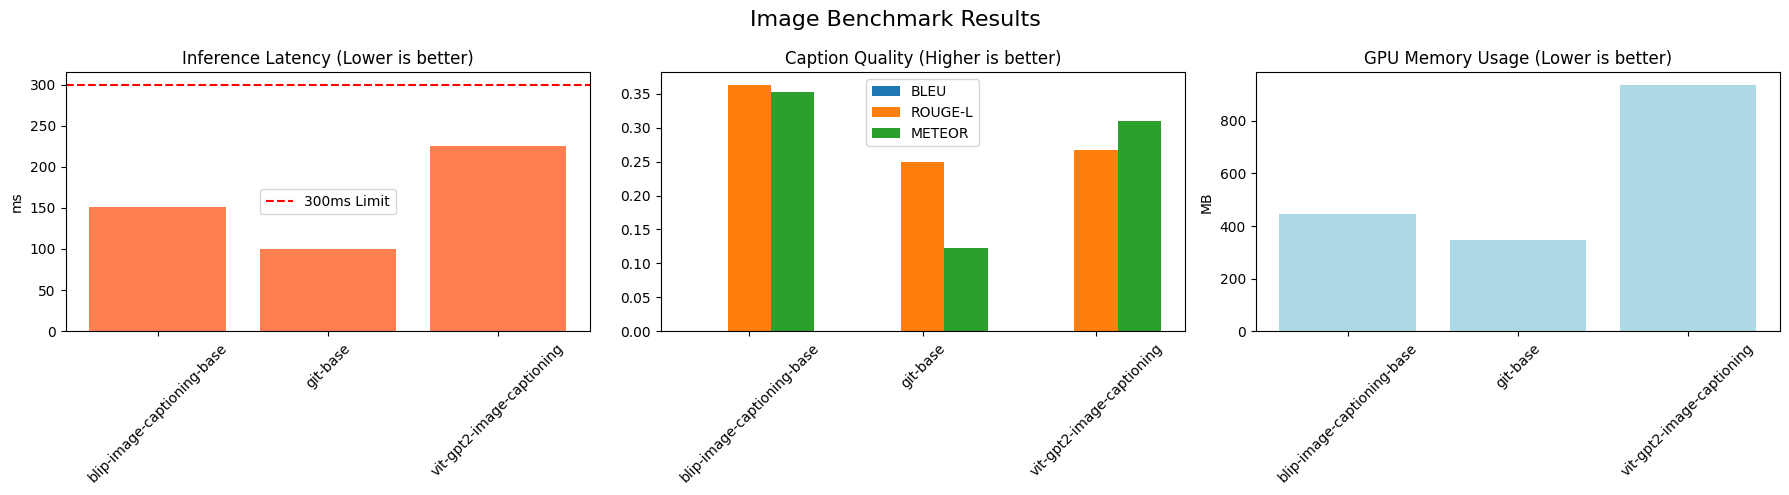

In [16]:
def plot_results(df, title):
    if df.empty: return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=16)
    
    # Latency Plot
    axes[0].bar(df["Model"], df["Avg Latency (ms)"], color='coral')
    axes[0].axhline(y=300, color='r', linestyle='--', label='300ms Limit')
    axes[0].set_title("Inference Latency (Lower is better)")
    axes[0].set_ylabel("ms")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()
    
    # Quality metrics
    x = np.arange(len(df["Model"]))
    width = 0.25
    axes[1].bar(x - width, df["BLEU"], width, label='BLEU')
    axes[1].bar(x, df["ROUGE-L"], width, label='ROUGE-L')
    axes[1].bar(x + width, df["METEOR"], width, label='METEOR')
    axes[1].set_title("Caption Quality (Higher is better)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df["Model"], rotation=45)
    axes[1].legend()
    
    # VRAM
    if "VRAM Usage (MB)" in df.columns and df["VRAM Usage (MB)"].iloc[0] != "-":
        axes[2].bar(df["Model"], df["VRAM Usage (MB)"], color='lightblue')
        axes[2].set_title("GPU Memory Usage (Lower is better)")
        axes[2].set_ylabel("MB")
        axes[2].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

plot_results(df_image_results, "Image Benchmark Results")


## 7. End-to-End System Simulation
Testing the best combination: Extract Frame -> Caption -> Classify


In [17]:
def end_to_end_test(image_path, model_id="Salesforce/blip-image-captioning-base"):
    print(f"\n--- End-to-End Test with {model_id} ---")
    classifier = DangerClassifier()
    captioner = Captioner(model_name=model_id)
    
    start_total = time.perf_counter()
    
    # 1. Image Load
    img = Image.open(image_path)
    
    # 2. Captioning
    cap_res = captioner.generate_caption(img)
    
    # 3. Classifying
    c_start = time.perf_counter()
    pred, reason = classifier.classify(cap_res['caption'])
    c_latency = (time.perf_counter() - c_start) * 1000
    
    total_lat = (time.perf_counter() - start_total) * 1000
    
    print(f"Caption:      {cap_res['caption']}")
    print(f"Danger Level: {pred} ({reason})")
    print(f"\nPipeline Latency Breakdown:")
    print(f" - Captioning:   {cap_res['latency_ms']:.1f} ms")
    print(f" - Classifier:   {c_latency:.1f} ms")
    print(f" - Total Time:   {total_lat:.1f} ms")

end_to_end_test(test_image_path)



--- End-to-End Test with Salesforce/blip-image-captioning-base ---
Loading Salesforce/blip-image-captioning-base on cuda...
Caption:      a red color with a white background
Danger Level: SAFE (No danger keywords)

Pipeline Latency Breakdown:
 - Captioning:   163.1 ms
 - Classifier:   0.1 ms
 - Total Time:   163.5 ms
